# **Titanic disaster ML modelling**

## Data Inspection and Preprocessing

In [76]:
# Import necessary libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns

# Open the training and testing datasets, and inspect the first few rows of the training dataset
train = pd.read_csv('../dataset/train.csv'); test = pd.read_csv('../dataset/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The target variable `Survived` is included on the training set. On the other hand, the testing set does not include the target variable, so we need to predict it.

In [77]:
# Let's do some basic data exploration to understand the structure of the dataset and identify any missing values or anomalies. We can check the shape of the dataset, the data types of each column, and the summary statistics for numerical columns.
print("Training dataset shape:", train.shape)
print("Testing dataset shape:", test.shape)
print("\nData types in training dataset:\n", train.dtypes)
print("\nSummary statistics for numerical columns in training dataset:\n", train.describe())

Training dataset shape: (891, 12)
Testing dataset shape: (418, 11)

Data types in training dataset:
 PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Summary statistics for numerical columns in training dataset:
        PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000 

In [78]:
# the target variable is included on the training dataset, but not on the testing dataset. We can check for missing values in the training dataset to see if there are any gaps in the data that we need to address before building our model.
print("\nMissing values in training dataset:\n", train.isnull().sum())


Missing values in training dataset:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [79]:
# Let's define the target variable and the features for our model. The target variable is typically the column we want to predict, while the features are the columns that we will use to make our predictions.
target = train['Survived']
train  = train.drop('Survived', axis=1)  # Assuming 'Survived' is the target variable

There are plenty of missing values on the `Cabin` feature, so it is better to drop it rhater than imputing the most common value (median). Further on, we can check if that variable presents high correlation with the target variable.

In [80]:
train, test = train.drop('Cabin', axis=1), test.drop('Cabin', axis=1)

For the `Age` feature, we can impute the most probable value (median), as we have 177 observations with null values and we don't want to delete the entire column as it may present an important correlation with the target variable `Survived`.

In [81]:
train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
test.Age.fillna(test.Age.median(), inplace=True)    # Fill missing values in 'Age' with the median age

/tmp/ipykernel_18474/4122061206.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Age.fillna(train.Age.median(), inplace=True)  # Fill missing values in 'Age' with the median age
/tmp/ipykernel_18474/4122061206.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

We proceed in a similar way for the 'Embarked' column, filling missing values with the most frequent value (mode) in that column.


In [82]:
train.Embarked.fillna(train.Embarked.mode()[0], inplace=True)  # Fill missing values in 'Embarked' with the most frequent value
test.Embarked.fillna(test.Embarked.mode()[0], inplace=True)    # Fill missing values in 'Embarked' with the most frequent value

/tmp/ipykernel_18474/3542603794.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train.Embarked.fillna(train.Embarked.mode()[0], inplace=True)  # Fill missing values in 'Embarked' with the most frequent value
/tmp/ipykernel_18474/3542603794.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

There's still one missing value in the `Fare` feature, specifically in the testing set. Let's impute the median.

In [83]:
test['Fare'].fillna(test['Fare'].median(), inplace=True)  # Fill missing values in 'Fare' with the median fare

/tmp/ipykernel_18474/1910750142.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].median(), inplace=True)  # Fill missing values in 'Fare' with the median fare


Now that the data is clenaed, let's take a look at data types.

In [84]:
train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

Most likely, variables like `PassengerID`, `Ticket` and `Name` are not going to be useful for our model, so we can drop them from both the training and testing datasets.

In [85]:
columns_to_drop = ['PassengerId', 'Name', 'Ticket']
train.drop(columns_to_drop, axis=1, inplace=True); test.drop(columns_to_drop, axis=1, inplace=True)

Variables `SibSp` and `Parch` refers to the number of siblings and parents of the passenger, respectively. We can create two new variables using feature engineer to improve the performance of the model. We also avoid multicollinearity as `FamilySize` is a linear combination of `SibSp` and `Parch`.

In [86]:
# Creating FamiliSize and IsAlone features
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)
train.drop(['SibSp', 'Parch'], axis=1, inplace=True)
test.drop(['SibSp', 'Parch'], axis=1, inplace=True)

Let's standarised numerical variables to be in the same range (with mean 1 and std 0)

In [87]:
# Standarised numerical columns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_cols = ['Age', 'Fare', 'Pclass', 'FamilySize']
train[numerical_cols] = scaler.fit_transform(train[numerical_cols])
test[numerical_cols] = scaler.transform(test[numerical_cols])

Now, let's convert the categorical variables into numerical format using one-hot encoding. This will allow us to use these features further on in our machine learning model.
We can use the `pd.get_dummies()` function to achieve this. Also, we need the categorical columns to be in numerical format for correlations.

In [88]:
# Convert Sex column to numerical values using mapping
train.Sex = train.Sex.map({'male': 0, 'female': 1})
test.Sex = test.Sex.map({'male': 0, 'female': 1})

For `Embarked`, we have three possible values: S, C or Q. Let's dummify them to be sure the three categories do not have an ordinal feature.

In [89]:
# Convert Embarked column to numerical values using one-hot encoding

train = pd.concat([train, pd.get_dummies(train.Embarked, prefix='Embarked', drop_first=True, dtype=int)], axis=1)
test = pd.concat([test, pd.get_dummies(test.Embarked, prefix='Embarked', drop_first=True, dtype=int)], axis=1)
train.drop('Embarked', axis=1, inplace=True)
test.drop('Embarked', axis=1, inplace=True) 

## Data Visualization

First, let's explore the correlations between variables

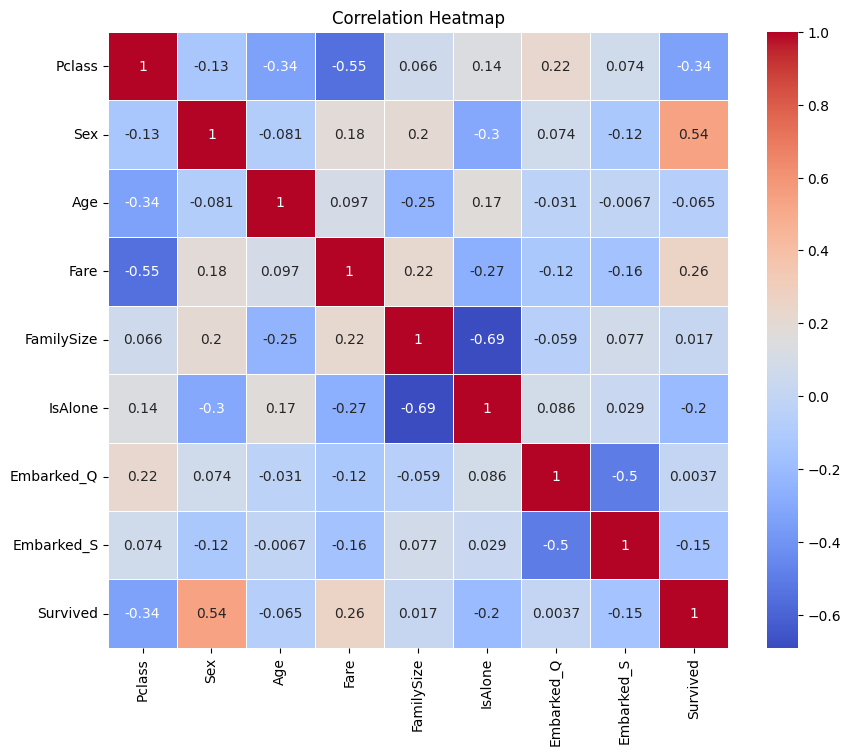

In [90]:
plt.figure(figsize=(10, 8))
df = pd.concat([train, target], axis=1)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

There're some features like `Embarked_Q` or `Age` which exhibit a very small correlation with the target variable `Survived`. However, both have significant correlations with other variables that may cause underfitting if we decide to drop them. So, from now, we will preserve all variables.

Let's check the imbalance of the target variable `Survived`

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


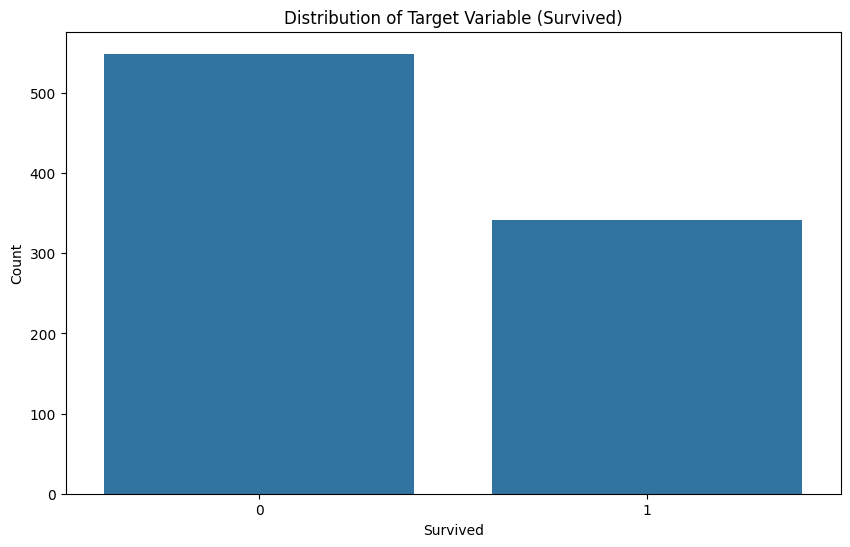

In [91]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Survived', data=pd.concat([train, target], axis=1))
plt.title('Distribution of Target Variable (Survived)')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

So the Class 0 (male) is larger than the Class 1 (female). Let's adjust our target and training set to have the same number of male and female passengers using `sklearn.resample`

/home/pablo/anaconda3/envs/ml_env_linux/lib/python3.9/site-packages/seaborn/categorical.py:1271: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data


<Axes: xlabel='Survived', ylabel='count'>

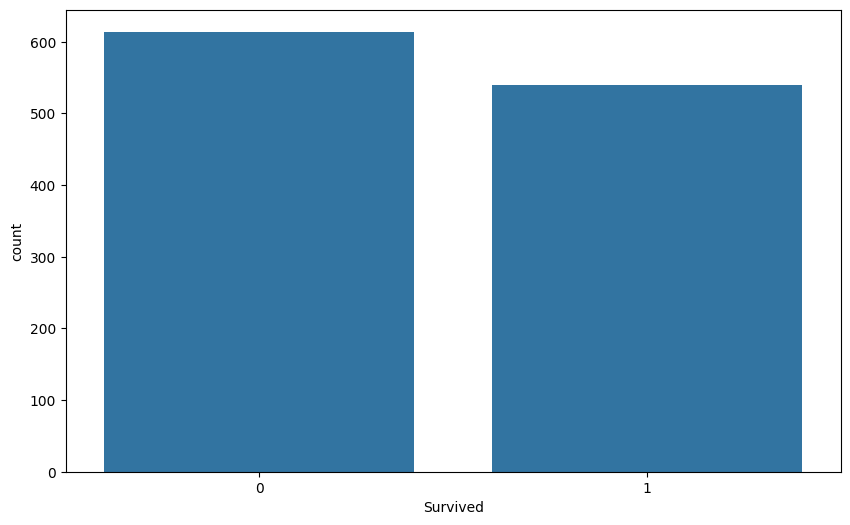

In [92]:
# We need to cut the training variables with respect to the Sex variable, in order to get the same number of 0s and 1s in the target variable. 
# This is important because if we have an imbalanced dataset, our model may be biased towards the majority class and perform poorly on the minority class.
train.Sex.value_counts()

from sklearn.utils import resample # Using resample to balance the dataset by oversampling the minority class
X_class0 = train[train.Sex == 0]  # Class 0
X_class1 = train[train.Sex == 1]  # Class 1
y_class0 = target[train.Sex == 0]  # Target variable for class 0
y_class1 = target[train.Sex == 1]  # Target variable for class 1

X_class1_upsampled, y_class1_upsampled = resample(X_class1, y_class1, replace=True, n_samples=len(X_class0), random_state=42)
X_balanced = pd.concat([X_class0, X_class1_upsampled])  # Combine the original class 0 with the upsampled class 1
y_balanced = pd.concat([y_class0, y_class1_upsampled])

plt.figure(figsize=(10, 6))
sns.countplot(x=y_balanced)

So now we have a balanced dataset with an equal number of samples for both classes, which should help our model perform better on the minority class.

## ML models for predicting if a passenger survived

Now we are ready to test some ML models and check their performance on predicting over the testing set. We will try with Logistic Regression, Random Forest and XGBoost, and if so, we will check a Neural Network to improve the performance.

### Logistic Regression

In [ ]:
# Let's import the necessary libraries for building and evaluating our machine learning model. We will use a simple logistic regression model for this task.
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(random_state=42)
LR.fit(X_balanced, y_balanced)

# First, we will make predictions on the training dataset to evaluate the performance of our model. We can use metrics such as accuracy, precision, recall, and F1-score to assess how well our model is performing.
from sklearn.metrics import classification_report, confusion_matrix
y_pred_train = LR.predict(X_balanced)
print("Classification Report for Training Data:\n", classification_report(y_balanced, y_pred_train))

Classification Report for Training Data:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82       614
           1       0.78      0.83      0.80       540

    accuracy                           0.81      1154
   macro avg       0.81      0.81      0.81      1154
weighted avg       0.81      0.81      0.81      1154

Confusion Matrix for Training Data:
 [[487 127]
 [ 94 446]]


In [ ]:
# Predicting the target variable for the testing dataset using the trained logistic regression model. We will then create a submission file in the required format for the Kaggle competition.
y_pred_test = LR.predict(test)
submission = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test})
submission.to_csv('../submissions/submission_LR.csv', index=False)

### Random Forest Classifier

In [96]:
# Let's try with a random forest classifier to see if we can improve our model's performance. Random forests are an ensemble learning method that can capture complex relationships in the data and often perform well on classification tasks.
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state=42)
RF.fit(X_balanced, y_balanced)
y_pred_train_rf = RF.predict(X_balanced)
print("Classification Report for Training Data (Random Forest):\n", classification_report(y_balanced, y_pred_train_rf))

Classification Report for Training Data (Random Forest):
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       614
           1       0.99      0.98      0.98       540

    accuracy                           0.99      1154
   macro avg       0.99      0.98      0.99      1154
weighted avg       0.99      0.99      0.99      1154



In [97]:
# Predicting and submitting results for the random forest model
y_pred_test_rf = RF.predict(test)
submission_rf = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test_rf})
submission_rf.to_csv('../submissions/submission_RF.csv', index=False)

### XGBoost

In [98]:
# Import the XGBoost classifier and train the model
from xgboost import XGBClassifier
XGB = XGBClassifier(random_state=42)
XGB.fit(X_balanced, y_balanced)
y_pred_train_xgb = XGB.predict(X_balanced)
print("Classification Report for Training Data (XGBoost):\n", classification_report(y_balanced, y_pred_train_xgb))

Classification Report for Training Data (XGBoost):
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       614
           1       0.98      0.96      0.97       540

    accuracy                           0.97      1154
   macro avg       0.97      0.97      0.97      1154
weighted avg       0.97      0.97      0.97      1154



In [99]:
# Predictions on the test dataset using the XGBoost model and creating a submission file
y_pred_test_xgb = XGB.predict(test)
submission_xgb = pd.DataFrame({'PassengerId': test.index + 892, 'Survived': y_pred_test_xgb})
submission_xgb.to_csv('../submissions/submission_XGB.csv', index=False)

In [101]:
pd.read_csv('../submissions/submission_XGB.csv')

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
